### Bulk RNA-seq Deconvolution with Geneformer Embeddings
This tutorial covers end-to-end bulk RNA-seq deconvolution in DECONVersation using Geneformer embeddings. It walks through extracting embeddings from bulk and single-cell reference data, building signature matrices, and estimating cell type proportions with all solvers available in DECONVersation. Performance is assessed against ground truth using RMSE and Pearson correlation. While this tutorial uses Geneformer, the workflow is fully compatible with Cell2Sentence, CellHermes and scGPT. <br>

#### Import Libraries

In [1]:
import sys
import os
import pandas as pd
import numpy as  np
import scanpy as sc
import deconversation
deconversation.__file__
from deconversation import embeddings, preprocessing, deconvolution, visualization, evaluation

/nfs/home/aoku/.local/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


geneformer successfully imported.
cell2sentence is not installed. Skipping related functions.
cellhermes is not installed. Skipping related functions.
scGPT is not installed. Skipping related functions.
scVI successfully imported.


#### Step 1: Load data

Here we use a PBMC bulk RNAseq dataset from [Hoek et al](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0118528). Geneformer requires Ensembl IDs, so we mapped our gene symbols back to Ensembl IDs using DECONVersation's `preprocessing.gene_id_name_map()`, which supports conversion in both directions (gene symbols → Ensembl IDs and Ensembl IDs → gene symbols).

We load the reference dataset from [Hao et al.](https://pubmed.ncbi.nlm.nih.gov/34062119/) Again, since Geneformer requires Ensembl IDs, we ensure that `adata.var.index` holds Ensembl IDs rather than gene symbols.

Ground-truth data comes from Hoek et al. (see above). There is a slight mismatch between the ground-truth labels and the cell types available in the reference, so we define a function to match cell types between the two datasets.

In [2]:
# Read in bulk RNAseq data
hoek_bulk = pd.read_csv("/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/bulk/hoek/hoek_counts.csv", index_col=0)

# Geneformer requires ensembl ids, DECONVersation supports mapping gene  names to ids 
hoek_bulk.index = preprocessing.gene_id_name_map(gene_list=hoek_bulk.index, mode="to_ensembl" ) 
hoek_bulk = hoek_bulk.loc[hoek_bulk.index.dropna()] # Drop unmapped genes

# Inspect bulk data
hoek_bulk.iloc[0:4, 0:4].head()

,HD30_PBMC_0,HD30_PBMC_1,HD30_PBMC_3,HD30_PBMC_7
ENSG00000259429,8,2,10,18
ENSG00000215529,35,35,30,26
ENSG00000231649,0,0,0,0
ENSG00000253542,0,0,0,0


In [3]:
# Load scRNA-seq reference data 
path_ref = "/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/geneformer/complete/haoSub.h5ad"
adata = sc.read_h5ad(path_ref)
adata = adata[adata.obs["broad_type"].isin(['B cells', 'Monocytes', 'NK cells', 'T cells', 'mDC', 'pDC'])]

# Ensure adata.var are ensembl ids (required for geneformer) - switch to gene names for scGPT. cellHermes and C2S
adata.var.index = adata.var.gene_id
adata = adata[:, adata.var.index.notnull()] 

/scratch/ipykernel_2319128/3326786052.py:7: ImplicitModificationWarning: Trying to modify index of attribute `.var` of view, initializing view as actual.
  adata.var.index = adata.var.gene_id


In [4]:
# load ground truth data
ground_truth = pd.read_csv("/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/bulk/hoek/hoek_facs.csv", index_col=0)
ground_truth = ground_truth.T

# Inspect data
ground_truth.iloc[0:4, 0:4].head()

,T cell,Monocytes,B cells,mDC
HD30_PBMC_0,0.514,0.155,0.043,0.0264
HD30_PBMC_1,0.457,0.214,0.048,0.0251
HD30_PBMC_3,0.580,0.153,0.042,0.0172
HD30_PBMC_7,0.578,0.135,0.066,0.0184


#### Step 2: Create signature matrix using scRNA reference data

Here we use DECONVersation's `preprocessing.create_signature_matrix()` to build a signature matrix. This averages gene expression across cell types, producing a gene-by-cell-type table covering every unique cell type in the reference dataset.

In [5]:
sig_mat = preprocessing.create_signature_matrix(adata = adata,
                                  sample_col = "batch", # batch or donor id column
                                  cell_type_col = "broad_type", # cell type column to average 
                                  groupby = "broad_type",
                                  output_path = None)

# Transpose for embedding extraction
sig_mat = sig_mat.T

# Inspect signature matrix
sig_mat.iloc[0:4, 0:4].head()

/gpfs/commons/groups/compbio/projects/rf_condas/deconv_gf_test/lib/python3.10/site-packages/deconversation/preprocessing.py:259: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  signature = expr.groupby(groupby).mean().T


gene_id,ENSG00000121410,ENSG00000268895,ENSG00000148584,ENSG00000175899
broad_type,,,,
B cells,0.217336,0.031785,0.000449,0.001496
Monocytes,0.349243,0.037201,0.000062,0.002642
NK cells,0.086643,0.009497,0.000167,0.009497
T cells,0.267866,0.019023,0.000210,0.009827


#### Step 3: Extract geneformer embeddings on signature matrix and bulk data

Here we extract Geneformer embeddings from both the signature matrix and the bulk RNA-seq dataset (Hoek et al.) using Geneformer's zero-shot model from `ctheodoris/Geneformer`. Embedding extraction writes intermediate files, such as the tokenized dataset. We set `delete_temp_files=True` so these are removed automatically once extraction finishes. Set it to `False` if you want to keep them.

In [7]:
# Extract geneformer embeddings on signature matrix
sig_mat_gf = embeddings.extract_embs(
    bulk_df = sig_mat,
    mode = "geneformer",
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "ctheodoris/Geneformer",
    delete_temp_files = True
)

In [9]:
# Extract geneformer embeddings on bulk data
bulk_gf = embeddings.extract_embs(
    bulk_df = hoek_bulk.T, # sample x ensembl id
    mode = "geneformer",
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "ctheodoris/Geneformer",  # Default geneformer model
    delete_temp_files = True # if True, delete all temporary files created whiile extracting embeddings
)

#### Step 3:  Run deconvolution

Here we run deconvolution with `deconvolution.run_all_deconv()`, which runs every solver available in DECONVersation. Deconvolution can also be run with `deconvolution.run_deconv()`, which uses NNLS as its default solver. DECONVersation currently supports `nnls`, `dwls` (solver only), `ridge`, `elasticnet`, and `nusvr`.

In [10]:
# Run deconvolution
results = deconvolution.run_all_deconv(bulk_df = bulk_gf.T, 
                         signature_df = sig_mat_gf.T)

# Harmonize results to match ground truth
def harmonize_columns(df):
    df = df.copy()
    if "pDC" in df.columns and "mDC" in df.columns:
        df["mDC"] = df["mDC"] + df["pDC"]
        df = df.drop(columns=["pDC"])
    elif "pDC" in df.columns:       
        df = df.rename(columns={"pDC": "mDC"})
    df = df.rename(columns={"T cells": "T cell"})
    return df


# Harmonize results to match ground truth
results = {solver: harmonize_columns(df) for solver, df in results.items()}

Condition number: 11.51.
~1-10: signatures are well separated; NNLS is usually hard to improve materially with another solver.
Smallest singular value: 0.2006.
If value is close to zero, the signature matrix is ill-conditioned; estimated proportions may be unstable.
Max pairwise cosine similarity between cell types: 0.9558.
Most similar pair: NK cells vs T cells.
If value is close to 1, these cell types are highly similar and difficult to resolve separately.
Running solver: nnls
Finished in 0.00 seconds.
Running solver: nnls_mod
Finished in 0.00 seconds.
Running solver: dwls
Finished in 0.01 seconds.
Running solver: simplex
Finished in 0.01 seconds.
Running solver: ridge_simplex
Finished in 0.01 seconds.
Running solver: dwls_simplex
Finished in 0.01 seconds.
Running solver: ridge
Finished in 0.02 seconds.
Running solver: elasticnet
Finished in 0.00 seconds.
Running solver: nusvr
Finished in 0.20 seconds.
Running solver: simplex_nnls
Finished in 0.00 seconds.
Running solver: gradient_de

/gpfs/commons/groups/compbio/projects/rf_condas/deconv_gf_test/lib/python3.10/site-packages/deconversation/deconvolution.py:172: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  references = torch.tensor(references, dtype=torch.float32)
/gpfs/commons/groups/compbio/projects/rf_condas/deconv_gf_test/lib/python3.10/site-packages/deconversation/deconvolution.py:174: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mixture = torch.tensor(mixture, dtype=torch.float32)


Finished in 0.30 seconds.


#### Step 4: Visualize results

After running `deconvolution.run_all_deconv()`, the results can be visualized with `visualization.visualize_solvers()`, which plots correlation and RMSE across all solvers used. Setting `level="cell_type"` reports correlation and RMSE per cell type instead.

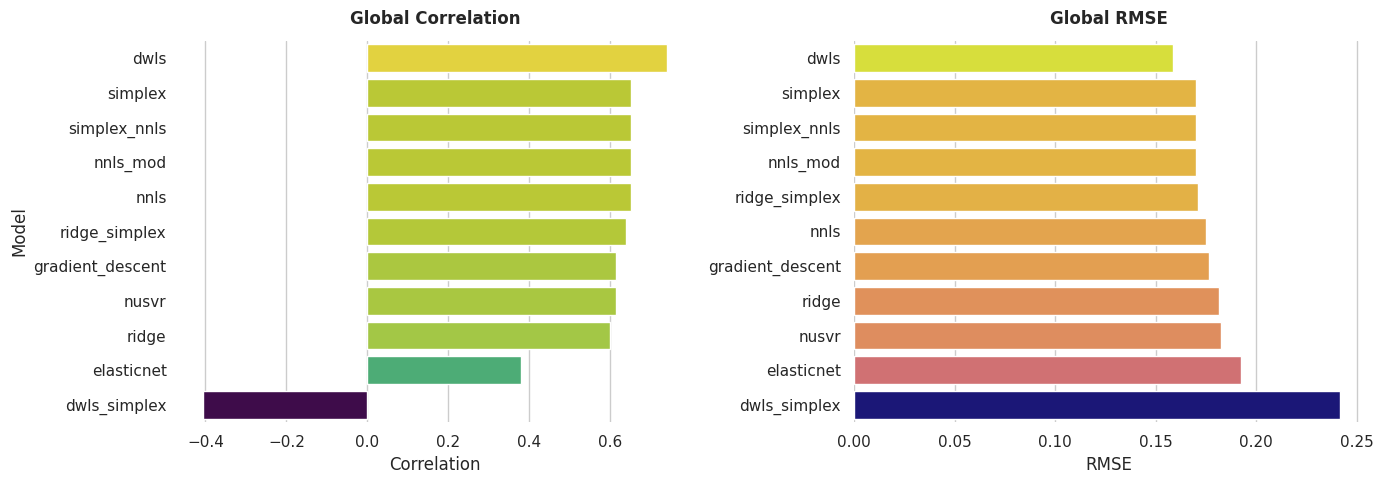

In [11]:
# Visualize results 
visualization.visualize_solvers(results, 
                  ground_truth, 
                  level=["global"])

#### Compare with PCA

Here we re-run the same analyses with PCA for comparison. We use `embeddings.extract_components()` to compute PCA embeddings, fitting on the signature matrix and applying the transform to the bulk data. This caps the number of components at the total number of cell types present in the signature matrix.

In [12]:
# Extract principal components frm bulk data and signature matrix 
# Fit on signature matrix and apply on  bulk
sig_mat_bulk_pca = embeddings.extract_components(bulk_df = hoek_bulk.T,
                                                 sig_mat = sig_mat,
                                                 mode = "pca",
                                                 transform = True)

bulk_pca = sig_mat_bulk_pca["pca_bulk"]
sig_mat_pca = sig_mat_bulk_pca["sig_pca"]

Variance explained by 6 PCs: 100.00%


In [13]:
# Run deconvolution
results_pca = deconvolution.run_all_deconv(bulk_df=bulk_pca.T, 
                                      signature_df=sig_mat_pca.T)

results_pca = {solver: harmonize_columns(df) for solver, df in results_pca.items()}

Condition number: 450650204.61.
~1-10: signatures are well separated; NNLS is usually hard to improve materially with another solver.
Smallest singular value: 3.381e-09.
If value is close to zero, the signature matrix is ill-conditioned; estimated proportions may be unstable.
Max pairwise cosine similarity between cell types: 0.3143.
Most similar pair: B cells vs T cells.
If value is close to 1, these cell types are highly similar and difficult to resolve separately.
Running solver: nnls
Finished in 0.00 seconds.
Running solver: nnls_mod
Finished in 0.00 seconds.
Running solver: dwls
Finished in 0.00 seconds.
Running solver: simplex
Finished in 0.00 seconds.
Running solver: ridge_simplex
Finished in 0.00 seconds.
Running solver: dwls_simplex
Finished in 0.01 seconds.
Running solver: ridge
Finished in 0.01 seconds.
Running solver: elasticnet
Finished in 0.01 seconds.
Running solver: nusvr
Finished in 0.00 seconds.
Running solver: simplex_nnls
  [skipped] simplex_nnls failed: RuntimeErro

/nfs/home/aoku/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.863e+07, tolerance: 4.769e+06
  model = cd_fast.enet_coordinate_descent(
/nfs/home/aoku/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.135e+07, tolerance: 5.151e+06
  model = cd_fast.enet_coordinate_descent(
/nfs/home/aoku/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality 

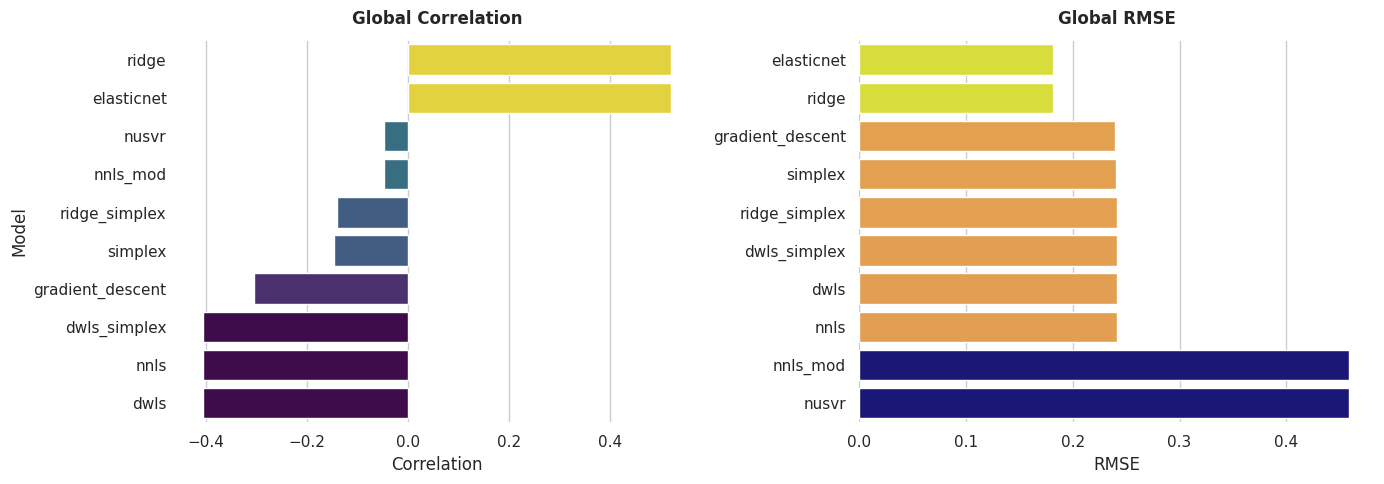

In [14]:
# Visualize results 
visualization.visualize_solvers(results_pca, 
                  ground_truth, 
                  level=["global"])

#### Alternative Approach Using core.py

Embeddings can also be extracted directly via DECONVersation's core functions. Rather than pre-computing embeddings separately, bulk RNA-seq and single-cell reference data (h5ad format) are passed directly to ```deconversation.deconverse()```, along with cell type and sample/donor annotations when single-cell data is provided. This  approach is compatible with all models supported by DECONVersation, including Geneformer, scGPT, Cell2Sentence, CellHermes, scVI, and PCA. <br>

In [20]:
res = deconversation.deconverse(
    bulk_df = "/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/bulk/hoek/hoek_counts.csv",
    adata = "/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/geneformer/complete/haoSub.h5ad",
    model = "ctheodoris/Geneformer",
    mode = "geneformer",
    cell_type_col = "broad_type",
    sample_col = "batch",
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/tempgf/")

Using model: geneformer


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 27.32it/s]

Bulk data rows are not ENSG ids, converting...
Extracting signature embedding...


  0%|          | 0/1 [00:00<?, ?it/s]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 148.15it/s]

Extracting bulk embedding...


  0%|          | 0/1 [00:00<?, ?it/s]

Solving deconvolution...


In [21]:
def harmonize_columns(df):
    df = df.copy()
    if "pDC" in df.columns and "mDC" in df.columns:
        df["mDC"] = df["mDC"] + df["pDC"]
        df = df.drop(columns=["pDC"])
    elif "pDC" in df.columns:       
        df = df.rename(columns={"pDC": "mDC"})
    df = df.rename(columns={"T cells": "T cell"})
    return df


# Harmonize results to match ground truth
results = harmonize_columns(res)

# Inspect results:
results.head()

broad_type,B cells,Monocytes,NK cells,Platelet,T cell,mDC
HD30_PBMC_0,0.0,0.364570,0.040373,0.309813,0.275984,0.009259
HD30_PBMC_1,0.0,0.399857,0.111210,0.310578,0.171286,0.007068
HD30_PBMC_3,0.0,0.337491,0.014011,0.316831,0.324410,0.007257
HD30_PBMC_7,0.0,0.308938,0.034612,0.325392,0.314413,0.016646
HD31_PBMC_0,0.0,0.401556,0.000000,0.314202,0.284242,0.000000


In [22]:
ground_truth.head()

,T cell,Monocytes,B cells,mDC,NK cells
HD30_PBMC_0,0.514,0.155,0.043,0.0264,0.178
HD30_PBMC_1,0.457,0.214,0.048,0.0251,0.168
HD30_PBMC_3,0.580,0.153,0.042,0.0172,0.148
HD30_PBMC_7,0.578,0.135,0.066,0.0184,0.132
HD31_PBMC_0,0.590,0.181,0.091,0.0163,0.045


In [23]:
evaluation.compute_correlation(true_df=ground_truth, pred_df=results)

np.float64(0.6441903227837804)

In [24]:
evaluation.compute_rmse(true_df=ground_truth, pred_df=results)

np.float64(0.16756961607937954)

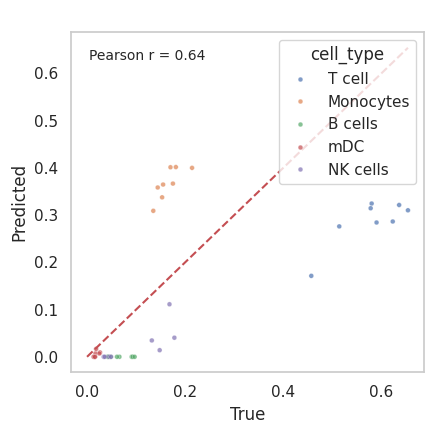

In [28]:
import matplotlib.pyplot as plt
plt.rcParams['axes.grid'] = False
visualization.plot_true_vs_predicted(y_true_df=ground_truth, 
                                     y_pred_df=results, 
                                     stratify_by_celltype=False)